# Customer Personality Prediction

## Machine Learning Project Workflow

This project follows the standard end-to-end machine learning pipeline:

* Problem Definition
* Data Collection and Cleaning
* Exploratory Data Analysis (EDA)
* Data Preprocessing and Feature Engineering
* Model Development and Training
* Model Evaluation and Selection

## 1. Problem Definition

The objective of this project is to help a company improve its marketing strategy by understanding the characteristics of its customers.

To grow its customer base and increase engagement, the company plans to introduce personalized product packages. Achieving this requires grouping customers based on their purchasing behavior, demographics, and overall personality traits.

By identifying meaningful customer segments, the business can deliver targeted offers and marketing campaigns to the right audience, improving customer satisfaction and increasing the effectiveness of promotional efforts.

### What is Customer Personality Analysis?

Customer Personality Analysis is the process of studying customer characteristics, preferences, and purchasing behavior to gain a deeper understanding of different customer groups. Rather than treating every customer the same, businesses can identify distinct segments with similar interests and needs.

These insights allow organizations to personalize products, services, and marketing campaigns for each customer segment. Instead of advertising every new product to the entire customer database, businesses can focus their efforts on the audience that is most likely to respond positively. This targeted approach helps reduce marketing costs, improve conversion rates, and strengthen customer relationships.


# 2. Data Collection
- The dataset is downloaded from https://github.com/entbappy/Branching-tutorial/blob/master/marketing_campaign.zip

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime as dt

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv('marketing_campaign.csv', sep='\t')

In [4]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [5]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [6]:
df.shape

(2240, 29)

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


# Summary

In [8]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


# Info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [10]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

# 3. Exploratory Data Analysis (EDA)

In [11]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [12]:
df.dtypes

ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
Z_CostContac

In [13]:
columns = [column for column in df.columns if column != 'ID']
num_cols = [col for col in columns if df[col].dtype != 'O']
cat_cols = [col for col in columns if df[col].dtype == 'O']

In [14]:
print(f"We have {len(num_cols)} numerical features : {num_cols}")   # Numeric Columns
print(f"We have {len(cat_cols)} categorical features : {cat_cols}")   # Categorical Columns

We have 26 numerical features : ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
We have 2 categorical features : ['Education', 'Marital_Status']


### Feature Information

- **People**

    - **ID:** Customer's unique identifier
    - **Year_Birth:** Customer's birth year
    - **Education:** Customer's education level
    - **Marital_Status:** Customer's marital status
    - **Income:** Customer's yearly household income
    - **Kidhome:** No. of children in customer's household
    - **Teenhome:** No. of teenagers in customer's household
    - **Dt_Customer:** Date of customer's enrollment with the company
    - **Recency:** No. of days since customer's last purchase
    - **Complain:** 1 if the customer complained in the last 2 years, 0 otherwise

- **Products**

    - **MntWines:** Amount spent on wine in last 2 years
    - **MntFruits:** Amount spent on fruits in last 2 years
    - **MntMeatProducts:** Amount spent on meat in last 2 years
    - **MntFishProducts:** Amount spent on fish in last 2 years
    - **MntSweetProducts:** Amount spent on sweets in last 2 years
    - **MntGoldProds:** Amount spent on gold in last 2 years

- **Promotion**

    - **NumDealsPurchases:** No. of purchases made with a discount
    - **AcceptedCmp1:** 1 if customer accepted the offer in the 1st campaign, 0 otherwise
    - **AcceptedCmp2:** 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
    - **AcceptedCmp3:** 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
    - **AcceptedCmp4:** 1 if customer accepted the offer in the 4th campaign, 0 otherwise
    - **AcceptedCmp5:** 1 if customer accepted the offer in the 5th campaign, 0 otherwise
    - **Response:** 1 if customer accepted the offer in the last campaign, 0 otherwise

- **Place**

    - **NumWebPurchases:** No. of purchases made through the company’s website
    - **NumCatalogPurchases:** No. of purchases made using a catalogue
    - **NumStorePurchases:** No. of purchases made directly in stores
    - **NumWebVisitsMonth:** No. of visits to company’s website in the last month

In [15]:
for i in range(len(cat_cols)):
    print(df[cat_cols[i]].value_counts())
    print()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64



In [16]:
df[cat_cols[0]].value_counts().count()

np.int64(5)

In [17]:
df[cat_cols[1]].value_counts().count()

np.int64(8)

In [18]:
for i in range(len(cat_cols)):
    print("=================================")
    print(df[cat_cols[i]].value_counts(normalize= True) * 100)
    print("=================================")

Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: proportion, dtype: float64
Marital_Status
Married     38.571429
Together    25.892857
Single      21.428571
Divorced    10.357143
Widow        3.437500
Alone        0.133929
Absurd       0.089286
YOLO         0.089286
Name: proportion, dtype: float64


### Univariate Analysis

Univariate analysis focuses on examining a single variable at a time. The prefix **"uni"** means **"one,"** indicating that this type of analysis is concerned with understanding the distribution, characteristics, and patterns of an individual variable without considering its relationship with other variables.

### Other Types of Data Analysis

* **Bivariate Analysis:** Examines the relationship or association between two variables to identify potential correlations or trends.
* **Multivariate Analysis:** Involves analyzing three or more variables simultaneously to uncover complex relationships, patterns, and interactions within the dataset.

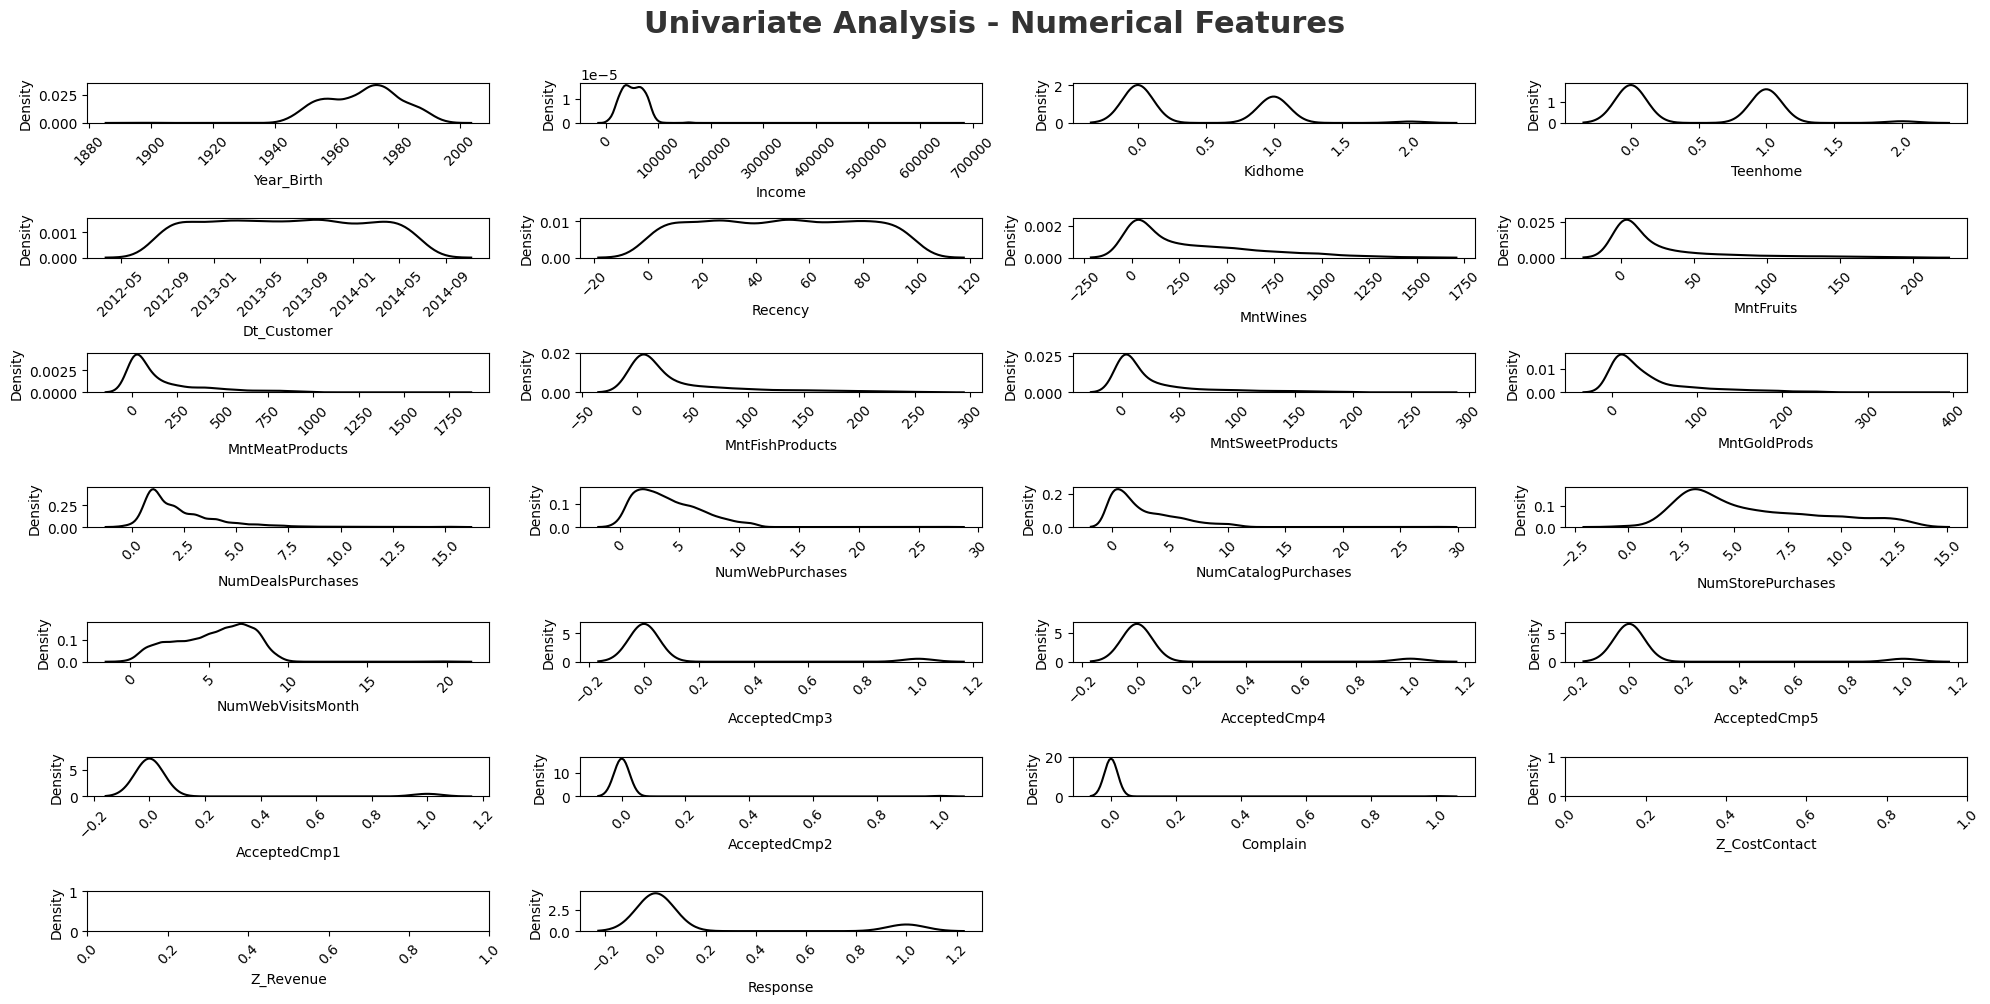

In [19]:
plt.figure(figsize=(20,10))
plt.suptitle('Univariate Analysis - Numerical Features', fontsize=22, fontweight='bold', alpha=0.8, y=1)

for i in range(len(num_cols)):
    plt.subplot(7,4,i+1)
    sns.kdeplot(x=df[num_cols[i]], color='black')
    plt.xlabel(num_cols[i])
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

*Report of the univariate analytis*
1. `Year_Birth` is left-skewed, most of the values falls in 1940-2000 range and has outliers.
2. `Income` is right-skewed, most of the values falls in 0 - <200000 range and has outliers.
3. `Kidhome`, `Teenhome` has constant values. Most of the values seems to be 0 or 1 and some of the values are 2.
4. `Dt_customer`, `Recency` are following a normal distribution
5. `MntWines`, `MntMeatProducts` are right-skewed, most of the values falls in 0 - 500 range and has outliers.
6. `MntFruits`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` is right-skewed, most of the values falls in 0-50 range and has outliers.
7. `NumDealsPurchases` is right-skewed, most of the values falls in 0-5 range and has outliers.
8. `NumWebPurchases`, `NumCatalogPurchases` are right skewed and most of the values falls in 0-10 range and have outliers.
9. `NumStorePurchases` is almost following a normal distribution and most of the values falls in 1 - 10 range and has outliers.
10. `NumWebVisitsMonth` is right-skewed, most of the values falls in 0- 10 range and has outliers.
11. `AcceptedCmp3`, `AcceptedCmp4`, `AcceptedCmp5`, `AcceptedCmp1`,`AcceptedCmp2` is right skewed and most of the values are 0 and some of the values are 1.
12. `Complain` has most of the values as 0 and we can see a little bit of the values as 1. 
13. `Z_CostContact`, `Z_Revenue` columns are not showing any graph. We'll graph those seperately and check what is happening.
14. `Response` has constant values as 0 and 1. 

<Axes: >

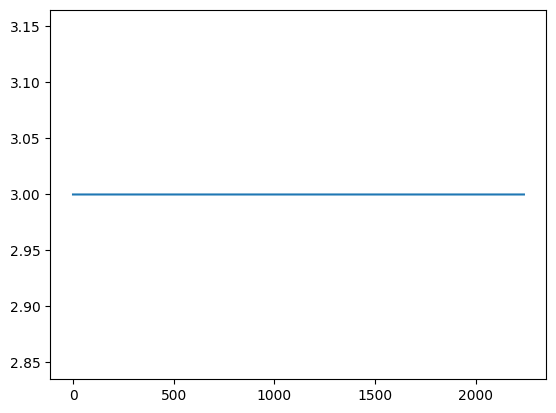

In [20]:
df.Z_CostContact.plot()

<Axes: >

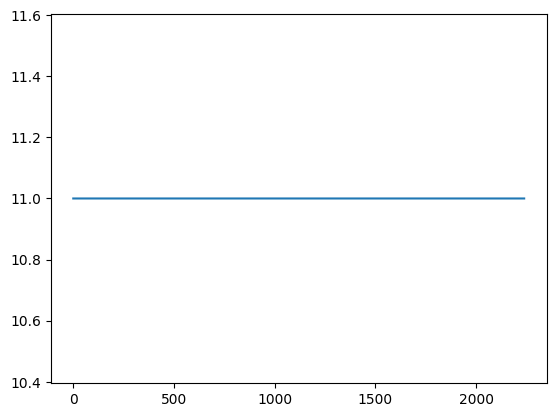

In [21]:
df.Z_Revenue.plot()

**As we can see**
- The column ```Z_CostContact```, ```Z_Revenue``` does have constant values. So, Drop this column

In [22]:
df.drop(columns=['Z_Revenue','Z_CostContact'], inplace=True)

In [23]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,0


## Categorical Features

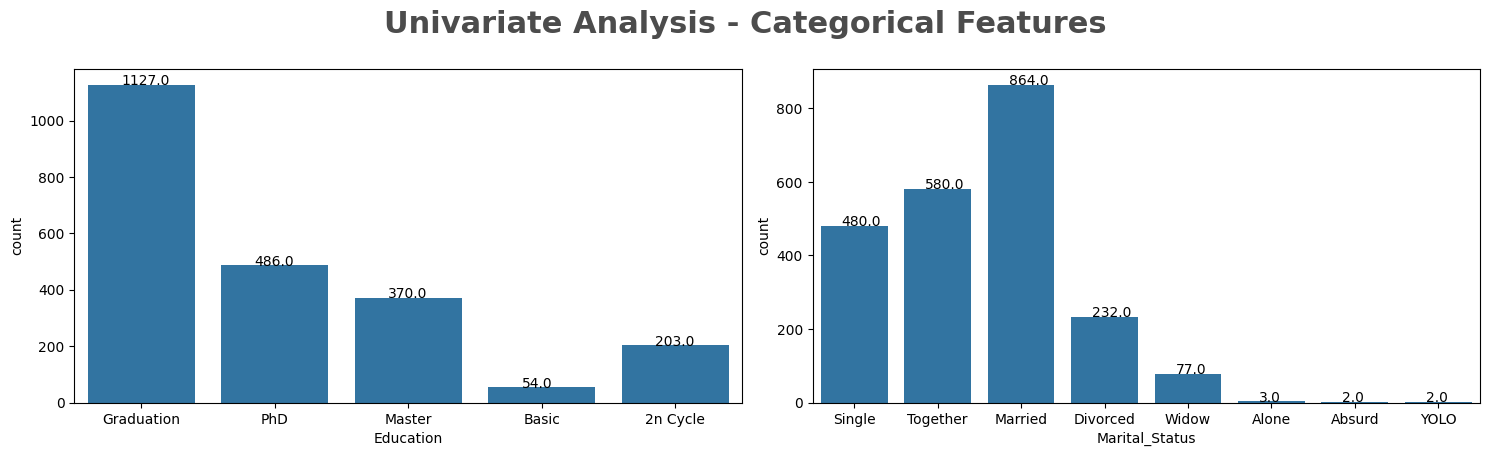

In [24]:
plt.figure(figsize=(15,8))
plt.suptitle("Univariate Analysis - Categorical Features", fontsize=22, fontweight='bold', alpha=0.7, y=1)

for i in range(0,len(cat_cols)):
    plt.subplot(2,2,i+1)
    ax=sns.countplot(x=df[cat_cols[i]])
    if df[cat_cols[i]].value_counts().count() < 10:
        for p in ax.patches:
            ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
        plt.xlabel(cat_cols[i])
        plt.tight_layout()
plt.show()

### Report

#### **Education**

* Most customers belong to the **Graduation** category, making it the most common education level in the dataset.
* A significant number of customers also have **PhD** and **Master's** degrees, while **Basic** and **2nd Cycle** education levels are less common.
* **2nd Cycle** refers to multidisciplinary degree programs that combine learning from two different academic disciplines.

#### **Marital_Status**

* The majority of customers are **Married**, with approximately **864** individuals in this category.
* Other common marital statuses include **Together**, **Single**, **Divorced**, and **Widow**.
* Categories such as **Alone**, **Absurd**, and **YOLO** contain very few records, indicating that they are rare within the dataset.


## Count of features based on years

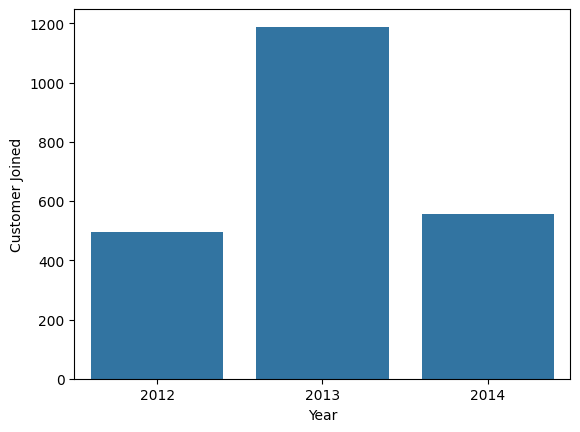

In [25]:
df1 = df.copy()
df1['Year'] = df1.Dt_Customer.dt.year
customer_joined_per_year = df1.groupby(by='Year', axis=0)[['ID']].count()
customer_joined_per_year = customer_joined_per_year.reset_index()
customer_joined_per_year.columns = ['Year', 'Customer Joined']
sns.barplot(data=customer_joined_per_year, x=customer_joined_per_year['Year'], y=customer_joined_per_year['Customer Joined'])
plt.show()

**Report**
- By this report, we can say that, most number of customers have joined in the year **2013**
- The number of customers got increased in year 2013 but in the year 2014, the number of customers got decreased.

# Multivariate Analysis

* Multivariate analysis is the analysis of more than one variable.
### Multicollinearity in Numerical features

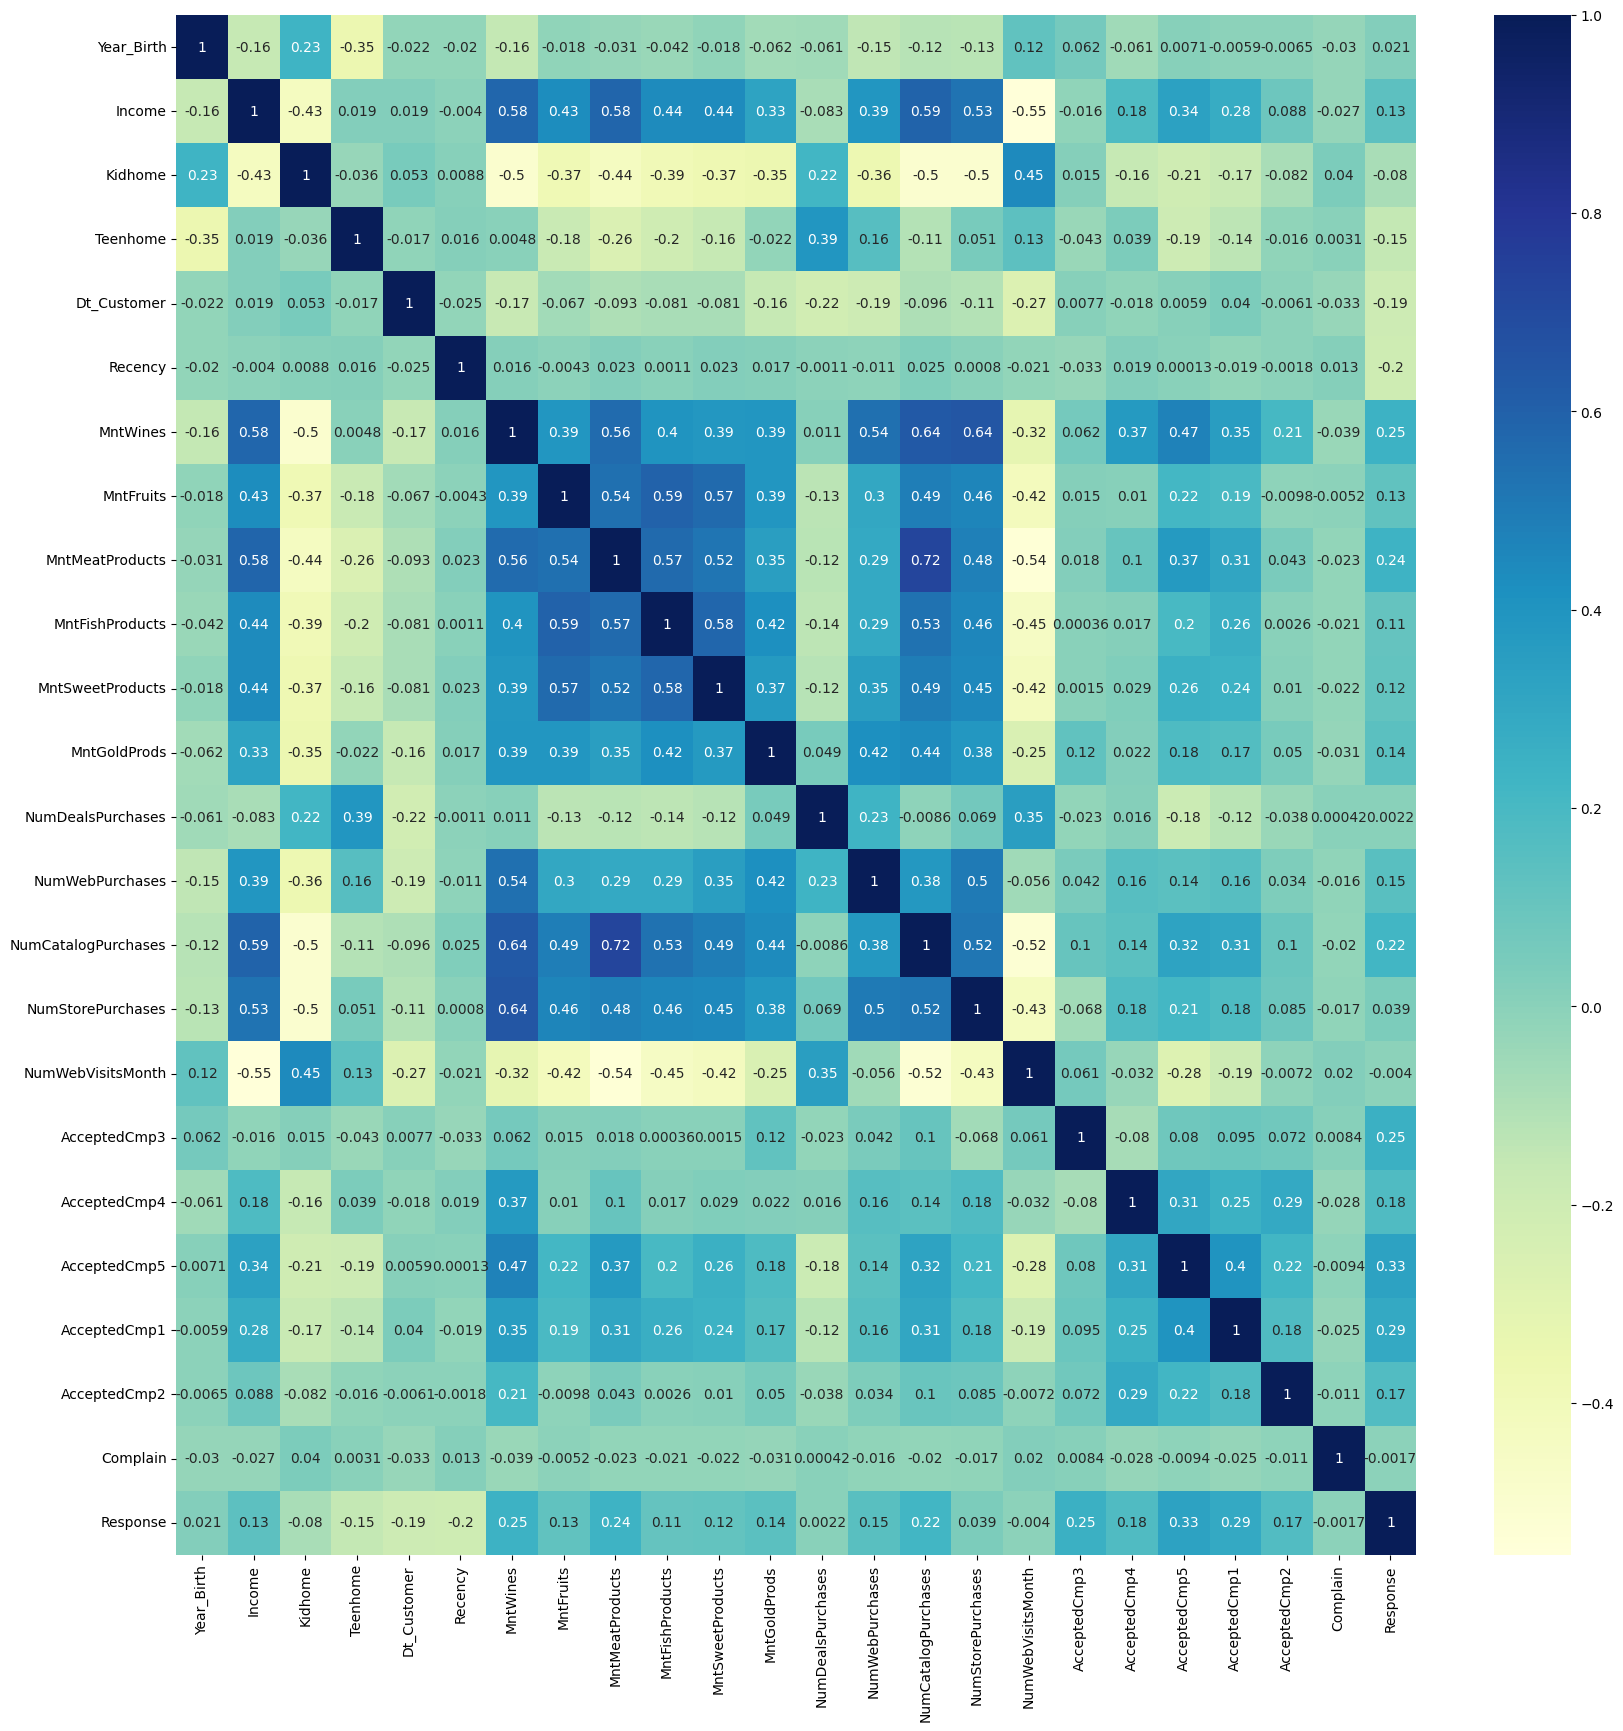

In [26]:
plt.figure(figsize=(20,20))
num_features = num_cols.copy()
num_features.remove('Z_CostContact')
num_features.remove('Z_Revenue')

sns.heatmap(df[num_features].corr(), annot=True, cmap='YlGnBu')
plt.show()

<Axes: >

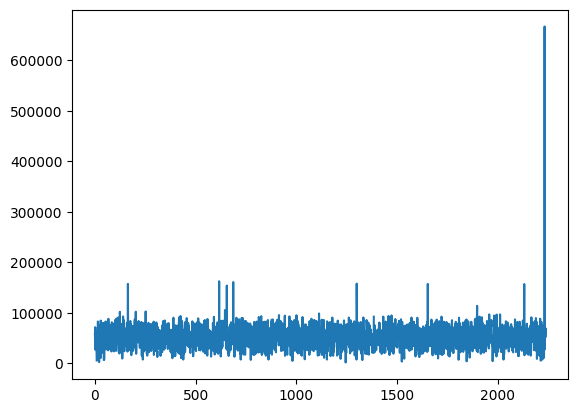

In [27]:
df.Income.plot()

**We can see that income does has some null values. Let's first impute those values**

In [28]:
#let's fill the income column with median income
df.Income.fillna(df.Income.median(), inplace=True)

In [29]:
df.Income.isna().sum()

np.int64(0)

* #### No any missing values now

## 4. Feature Engineering

* Will create new features that would be helpful to describe the profile of the customer

In [30]:
from datetime import datetime

raw_df = df.copy()  # Saving for reference

# Creating new field "Age" of customer
df['Age'] = 2026-df['Year_Birth']

# Encoding the Education column from (0 to 4)
df['Education'].replace({'Basic':0, '2n Cycle':1, 'Graduation':2, 'Master':3, 'PhD':4}, inplace=True)

# Encoding Marttial status to 0 and 1
df['Marital_Status'].replace({'Married':1, 'Together':1, 'Single':0,'Divorced':0,'Widow':0,'Alone':0,'Absurd':0,'YOLO':0}, inplace=True)

# No. of children(kidhome + Teenhome)
df['Children'] = df['Kidhome'] + df['Teenhome']

# Creating Family size
df['Family_size'] = df['Marital_Status'] + df['Children'] + 1

# Creating new field for total spending
df['Total_Spending']=df["MntWines"]+ df["MntFruits"]+ df["MntMeatProducts"]+ df["MntFishProducts"]+ df["MntSweetProducts"]+ df["MntGoldProds"]

# Total Promotion in different campaign
df["Total Promo"] =  df["AcceptedCmp1"]+ df["AcceptedCmp2"]+ df["AcceptedCmp3"]+ df["AcceptedCmp4"]+ df["AcceptedCmp5"]

# Total promotion customer responded to
df['Offers_Responded_To']=df['AcceptedCmp1']+df['AcceptedCmp2']+df['AcceptedCmp3']+df['AcceptedCmp4']+df['AcceptedCmp5']+df['Response']

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
today = datetime.today()
df['Days_as_Customer'] = (today-df['Dt_Customer']).dt.days

df['Parental Status'] = np.where(df['Children'] > 0, 1,0)

In [31]:
# Dropping columns which are already been used to create new features
df.drop(columns=['Year_Birth', 'Kidhome', 'Teenhome'], axis=1, inplace=True)

df.rename(columns={"Marital_Status": "Marital Status", "MntWines": "Wines", "MntFruits":"Fruits", "MntMeatProducts":"Meat", "MntFishProducts":"Fish", "MntSweetProducts":"Sweets", "MntGoldProds":"Gold", "NumWebPurchases": "Web", "NumStorePurchases":"Store", "NumDealsPurchases":"Discount Purchases"}, inplace=True)

In [32]:
df = df[["Age","Education","Marital Status","Parental Status","Children","Income","Total_Spending","Days_as_Customer","Recency","Wines","Fruits","Meat","Fish","Sweets","Gold","Web","Store","Discount Purchases","Total Promo","NumWebVisitsMonth"]]

In [33]:
columns = [col for col in df.columns if col != 'ID']

num_features = [feature for feature in columns if df[feature].dtype != 'O']

continuous_features = [feature for feature in num_features if len(df[feature].unique()) >= 10]

In [34]:
print(f"There are {len(num_features)} Numerical Features : {num_features}")
print(f"There are {len(num_features)} Continuous Features : {continuous_features}")

There are 20 Numerical Features : ['Age', 'Education', 'Marital Status', 'Parental Status', 'Children', 'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Store', 'Discount Purchases', 'Total Promo', 'NumWebVisitsMonth']
There are 20 Continuous Features : ['Age', 'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Store', 'Discount Purchases', 'NumWebVisitsMonth']


## Multicllinearity Check
Variance Inflation Factor(VIF)

* Multicollinearity occurs when there are two or more independent variables in a multiple regression model, which have a high correlation among themselves. When some features are highly correlated.
* Multicollinearity can be detected using various techniques, one such technique being the Variance Inflation Factor(VIF).

In [35]:
# pip install statsmodels

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def compute_vif(considered_features, df):
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1

    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

# Remove the datetime column which is not required for the vif checking
cont_features = continuous_features.copy()

# We will not check VIF for total spending, as it is the summation of Wines,Fruits,Meat,Fish,Sweets,Gold.
cont_features.remove('Total_Spending')
compute_vif(cont_features, df)

,Variable,VIF
0,Age,1.073532
1,Income,2.113963
2,Days_as_Customer,1.272999
3,Recency,1.004859
4,Wines,2.435214
5,Fruits,1.933090
6,Meat,2.362356
7,Fish,2.052923
8,Sweets,1.894877
9,Gold,1.457974


- Data has VIF less than 5 - So, No correlations

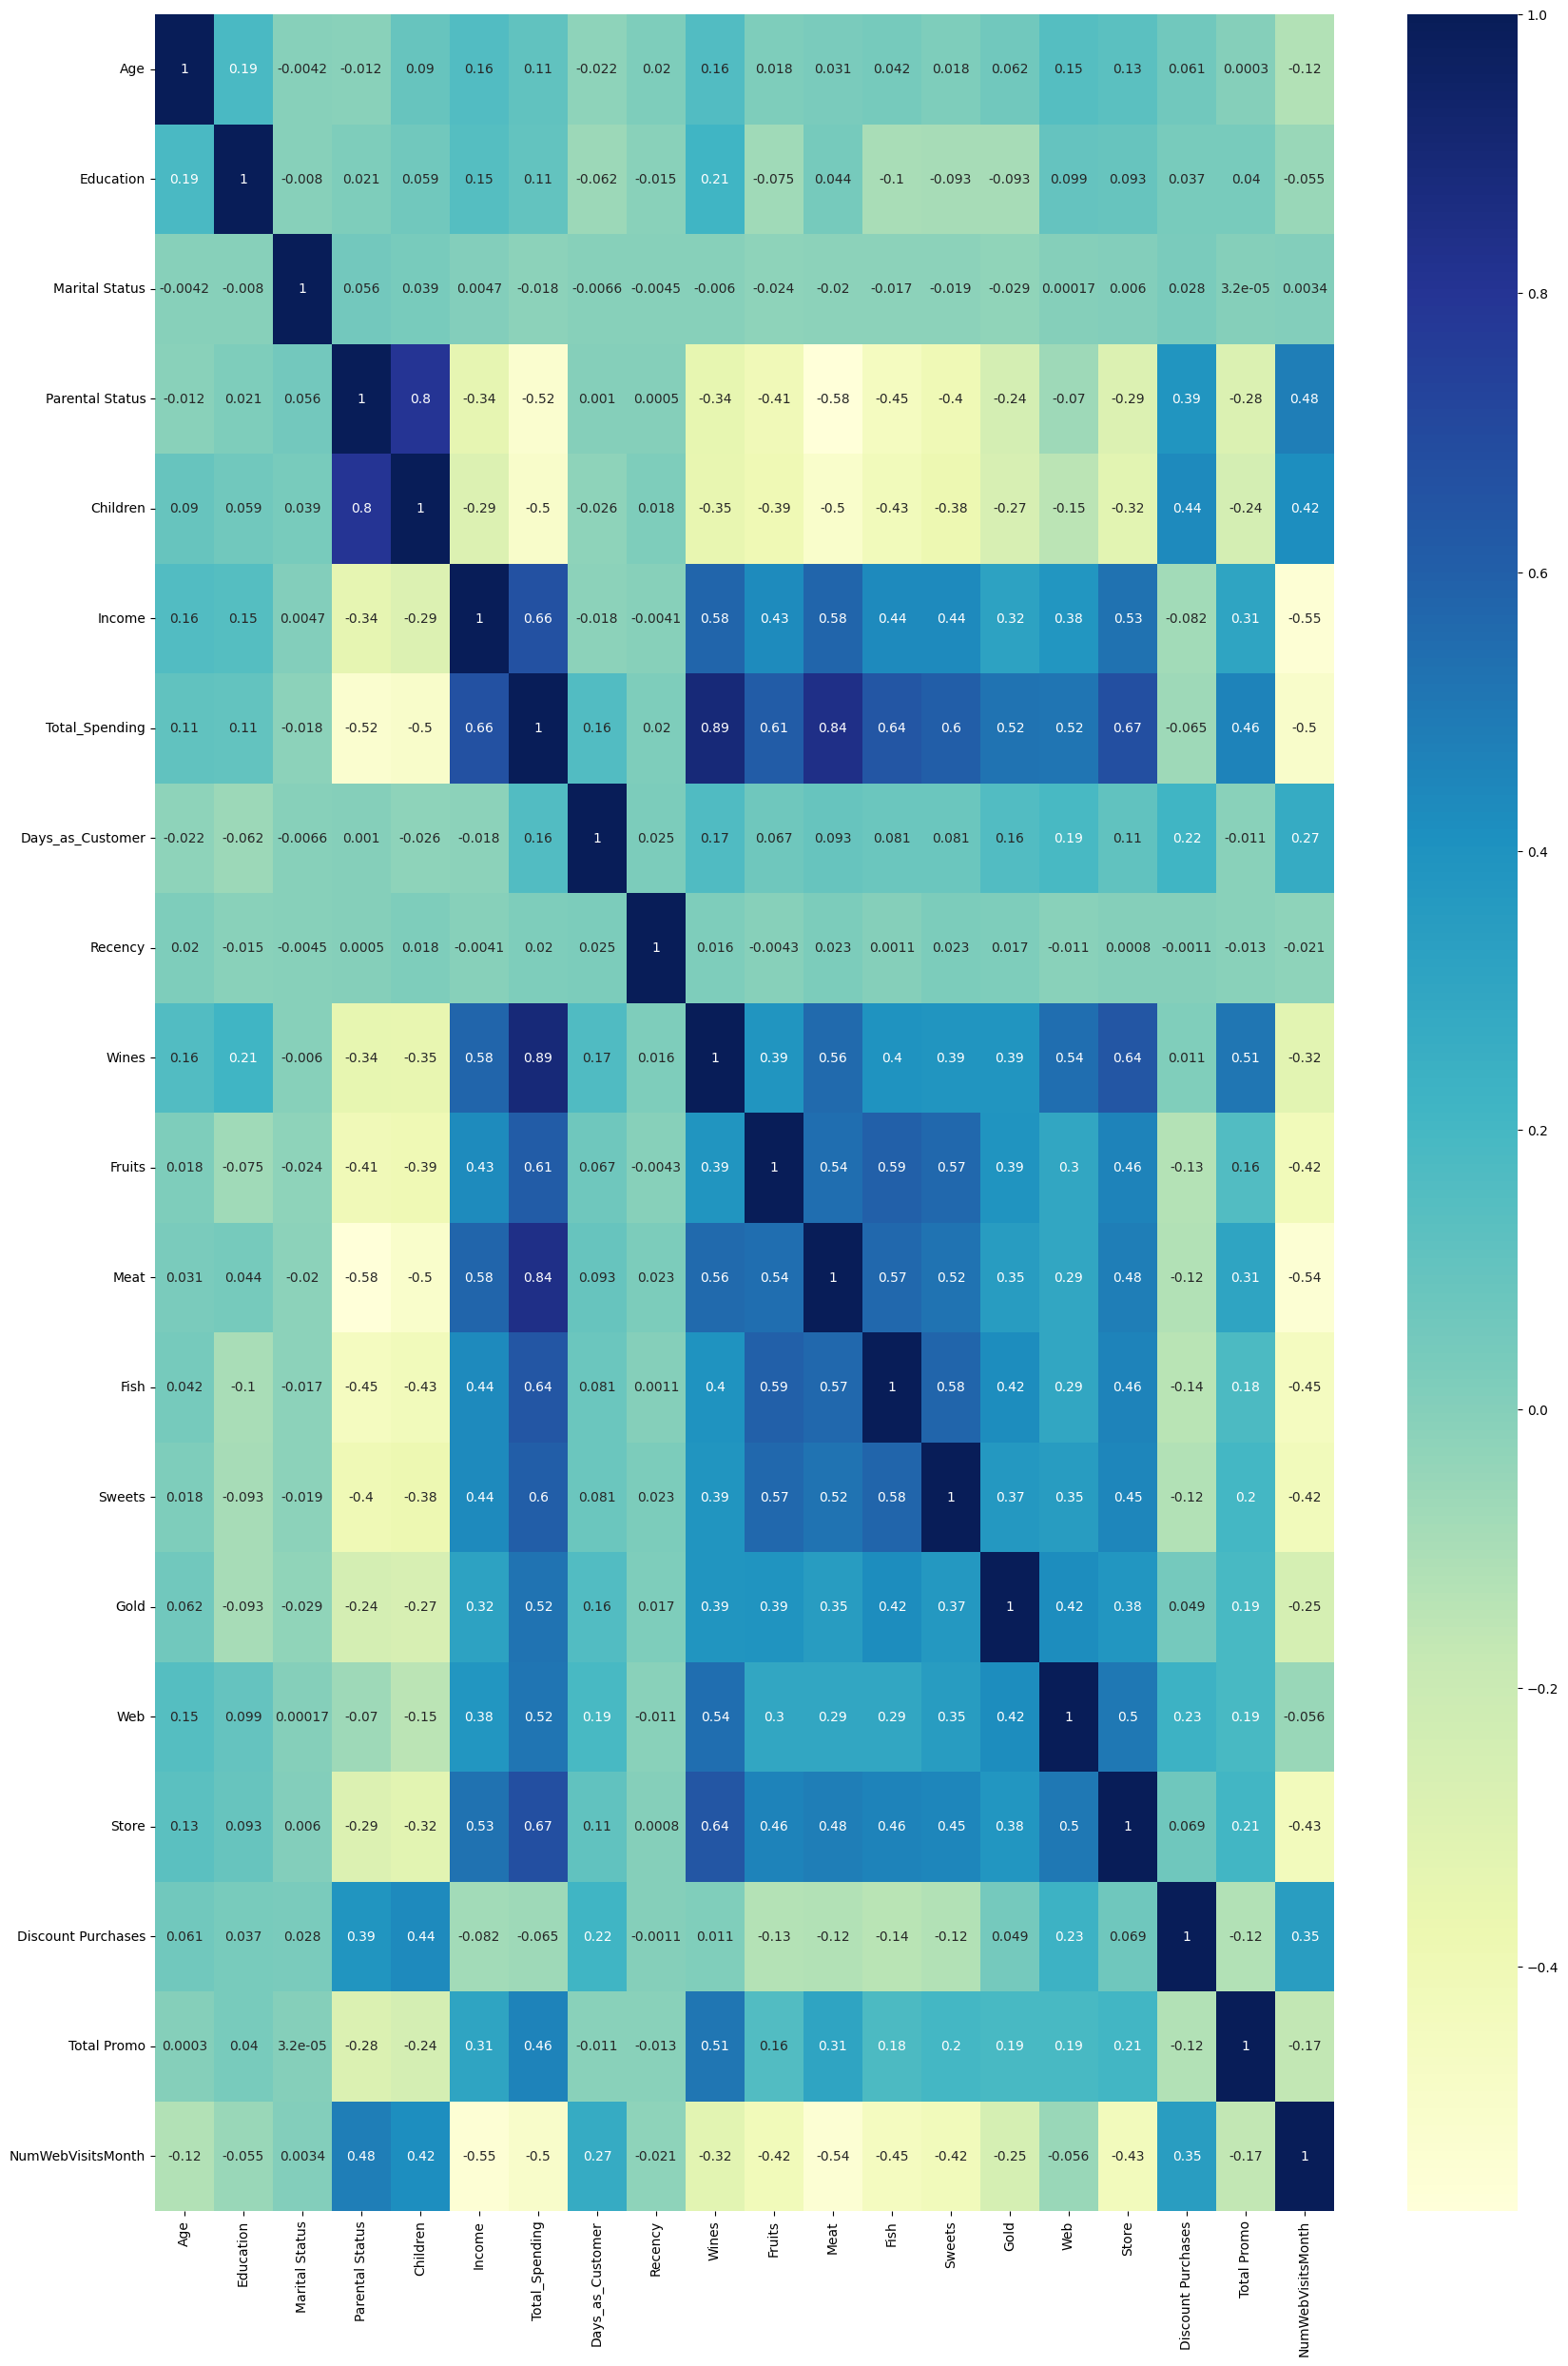

In [37]:
plt.figure(figsize=(20,30))
sns.heatmap(df[num_features].corr(), annot=True, cmap='YlGnBu')
plt.show()

- Checking null values

In [38]:
df.isnull().sum()

Age                   0
Education             0
Marital Status        0
Parental Status       0
Children              0
Income                0
Total_Spending        0
Days_as_Customer      0
Recency               0
Wines                 0
Fruits                0
Meat                  0
Fish                  0
Sweets                0
Gold                  0
Web                   0
Store                 0
Discount Purchases    0
Total Promo           0
NumWebVisitsMonth     0
dtype: int64

- We can see there is no any null values

Analysis Report:
- There is no any such target feature, so we can do clustering

## Visualization

- Who are most in count? men or women

In [39]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

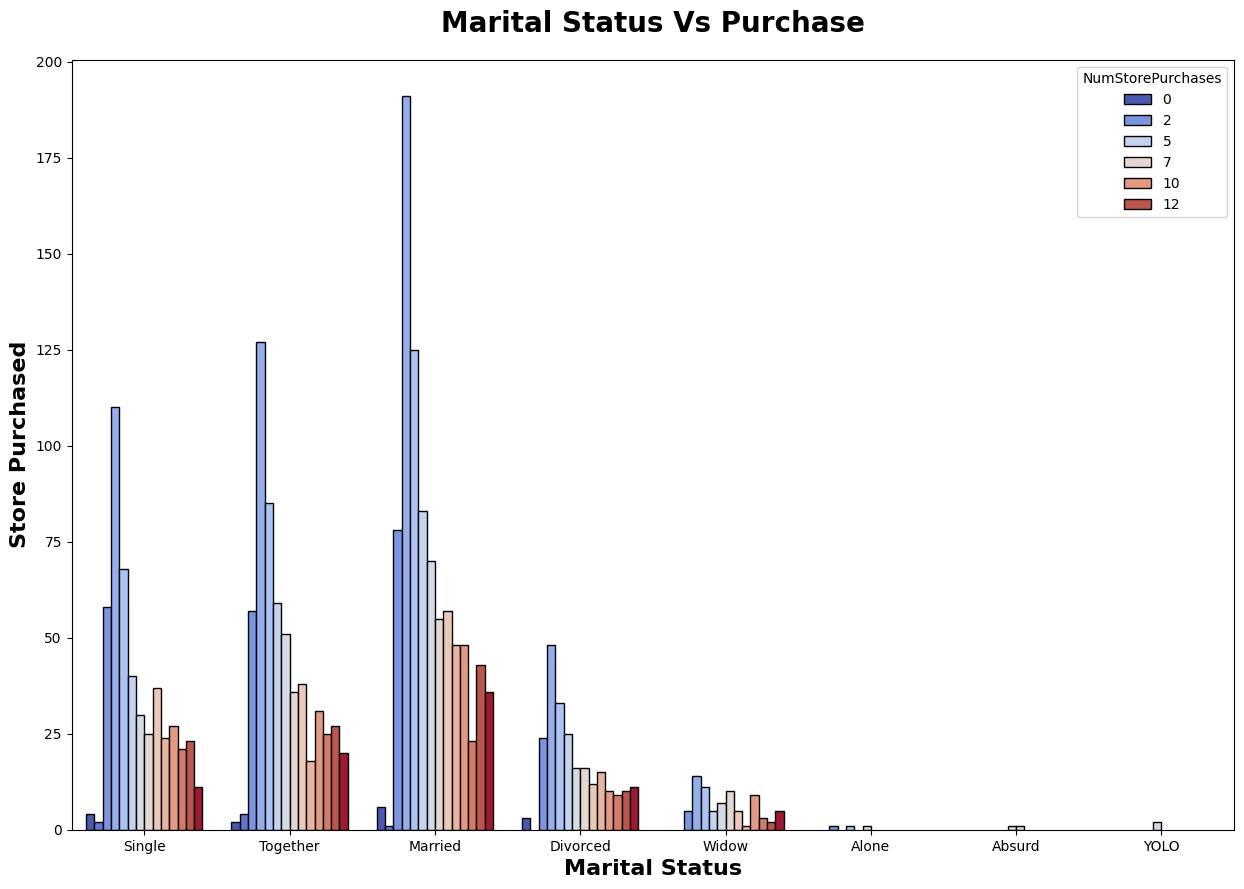

In [40]:
plt.subplots(figsize=(15,10))
sns.countplot(x='Marital_Status', hue='NumStorePurchases', data = df1, ec='black', palette='coolwarm')
plt.title('Marital Status Vs Purchase', weight='bold', fontsize=20, pad=20)
plt.xlabel('Marital Status', weight='bold', fontsize=16)
plt.ylabel('Store Purchased', weight='bold', fontsize=16)
plt.show()

**Report**
- As per the chart 'Married' bought most products followed by 'Together' and 'Single' but 'Divorced', 'Widow', 'Alone', 'Absurd', 'YOLO' bought very less

In [41]:
dates = []
for i in raw_df['Dt_Customer']:
    i = i.date()
    dates.append(i)

print(f"Newest Enrollment of customer {min(dates)}")
print(f"Oldest Enrollment of customer {max(dates)}")

Newest Enrollment of customer 2012-07-30
Oldest Enrollment of customer 2014-06-29


**Report**
- The dataset contains customer data from `2012-07-30` to `2014-06-29`

In [42]:
df.head()

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
0,69,2,0,0,0,58138.0,1617,5072,58,635,88,546,172,88,88,8,4,3,0,7
1,72,2,0,1,2,46344.0,27,4522,38,11,1,6,2,1,6,1,2,2,0,5
2,61,2,1,0,0,71613.0,776,4721,26,426,49,127,111,21,42,8,10,1,0,4
3,42,2,1,1,1,26646.0,53,4548,26,11,4,20,10,3,5,2,4,2,0,6
4,45,4,1,1,1,58293.0,422,4570,94,173,43,118,46,27,15,5,6,5,0,5


In [43]:
# Setting plotting options

sns.set_style("white")
sns.set(rc={"axes.facecolor":"#cce0ff","figure.facecolor":"#cce0ff"})
sns.set_context("poster",font_scale = .7)

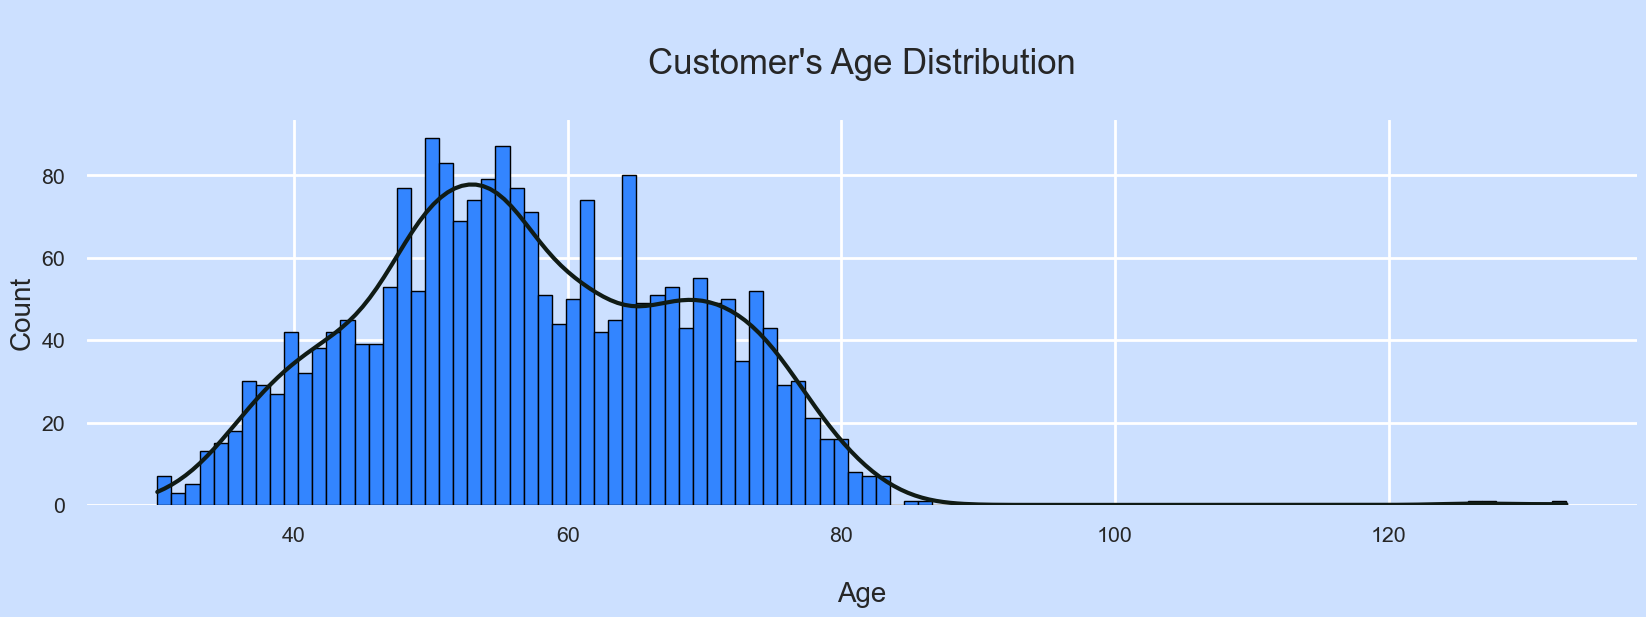

In [44]:
plt.subplots(figsize=(20, 5))
plt.title("Let's have a look on the distribution of customer's age :", weight="bold",fontsize=20, pad=20)

p = sns.histplot(df["Age"],color="#3385ff",kde=True,bins=100,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.set_title("\nCustomer's Age Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAge",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

**Reports**
- We can see it's distribution is normal but there are some outliers -> Which we can remove

- As we can seee most of the customers are from 20 to 80. So, we can filter the data by age <90

## Age Distribution of Customers

Let's have look again on distribution of customer's age


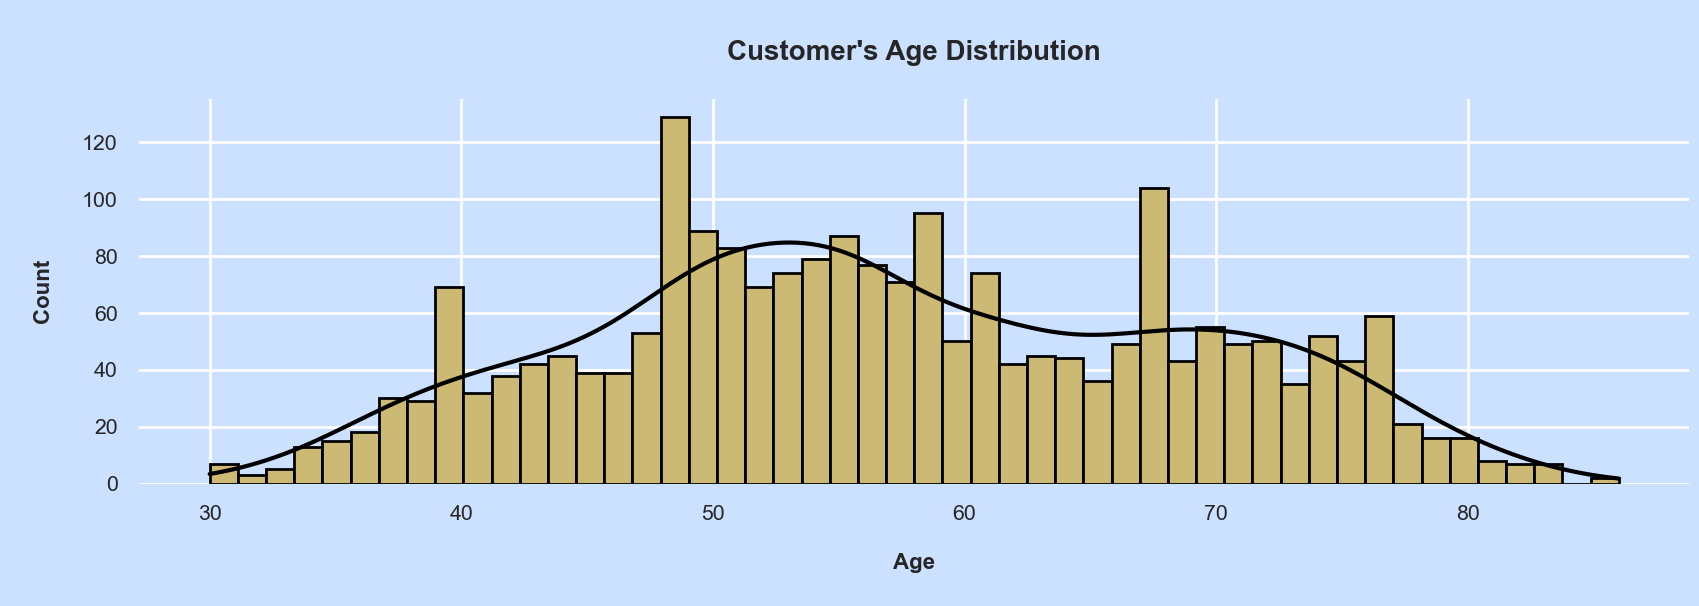

In [45]:
df = df[df['Age'] < 90]

# Let's plot now
print(f"Let's have look again on distribution of customer's age")

plt.subplots(figsize=(20,5))
p = sns.histplot(df['Age'], color='y', kde=True, bins=50, alpha=1, fill=True, edgecolor='black')
p.axes.lines[0].set_color('black')
p.axes.set_title("\nCustomer's Age Distribution\n",fontsize=20, weight='bold')
plt.xlabel('\nAge\n', fontsize=16, weight='bold')
plt.ylabel('\nCount\n', fontsize=16, weight='bold')
sns.despine(bottom=True, left=True)
plt.show()

**Report**
- Now we can see that distribution of customer's age is normal

## Customer's Income Spending Distribution

Let's have a look at customer's income and spending: 


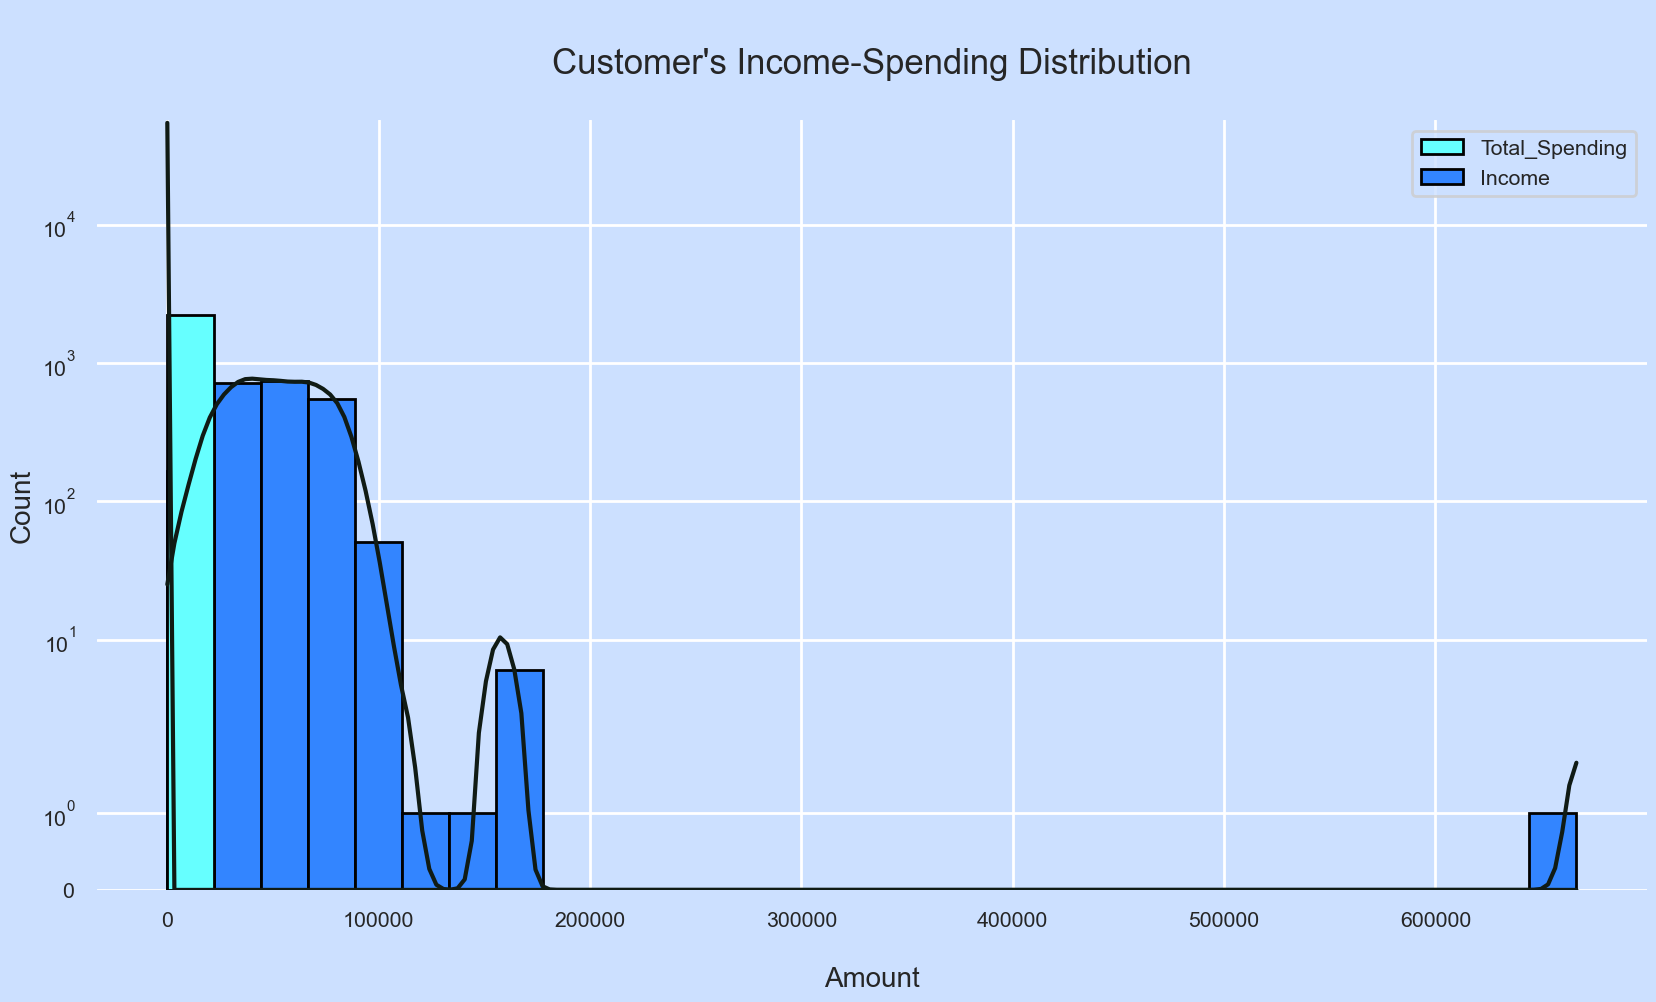

In [46]:
print(f"Let's have a look at customer's income and spending: ")
plt.subplots(figsize=(20,10))
p = sns.histplot(df[["Total_Spending", "Income"]], palette=["#66ffff","#3385ff"], kde=True, bins=30, alpha=1, fill=True, edgecolor='black')
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's Income-Spending Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAmount",fontsize=20)
sns.despine(left=True, bottom=True)
plt.show()

**Report**
- There are some outliers which are more than 6,00,000 -> So, we can filter them out

In [47]:
df = df[df["Income"] < 600000]

## Customer Income Vs Spending Distribution

Let's have a look again on the distribution of customer's income and spending :


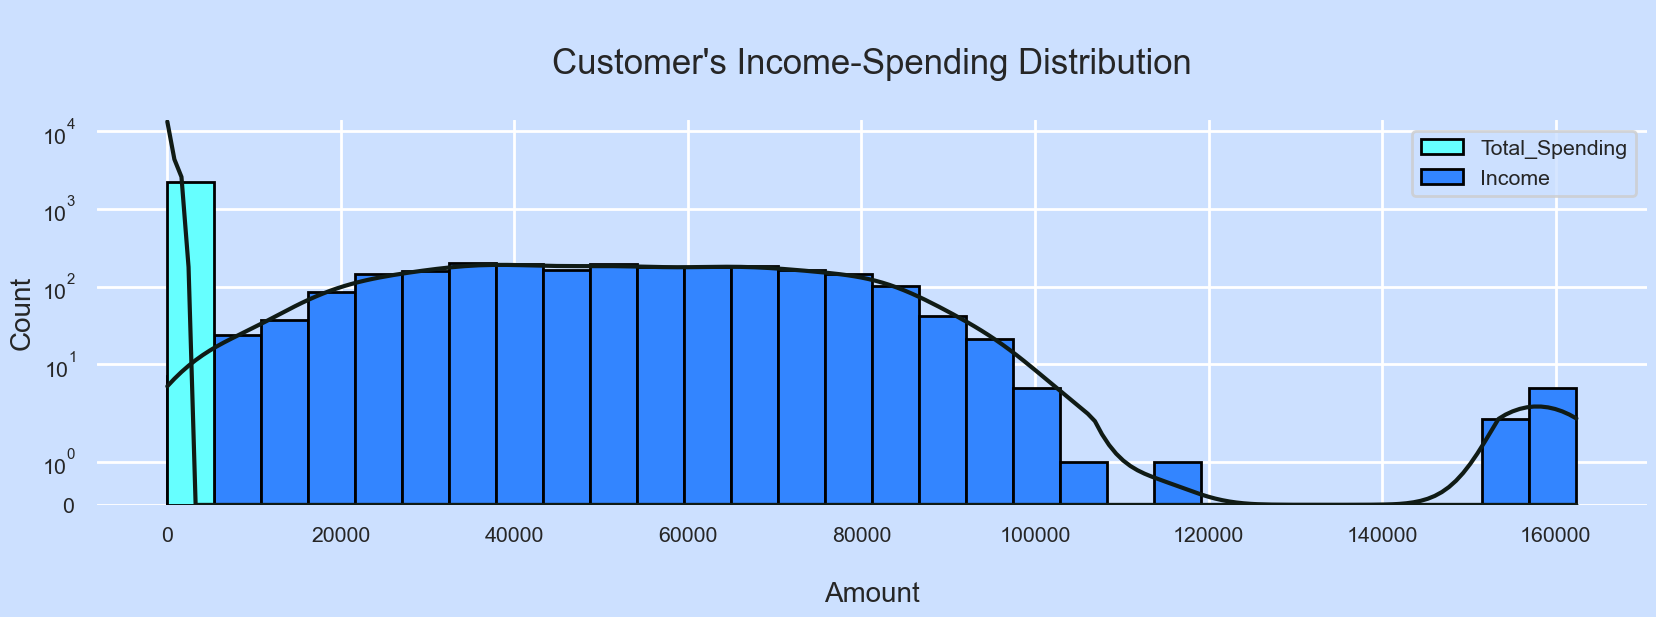

In [48]:
print(f"Let's have a look again on the distribution of customer's income and spending :")
plt.subplots(figsize=(20, 5))
p = sns.histplot(df[["Total_Spending","Income"]],palette=["#66ffff","#3385ff"],kde=True,bins=30,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's Income-Spending Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAmount",fontsize=20)
sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

- Most of the customers income range is in between 20000 to 80000
- Bust almost all customers spend very few portion of their income.

Let's have a look on the customer's education :


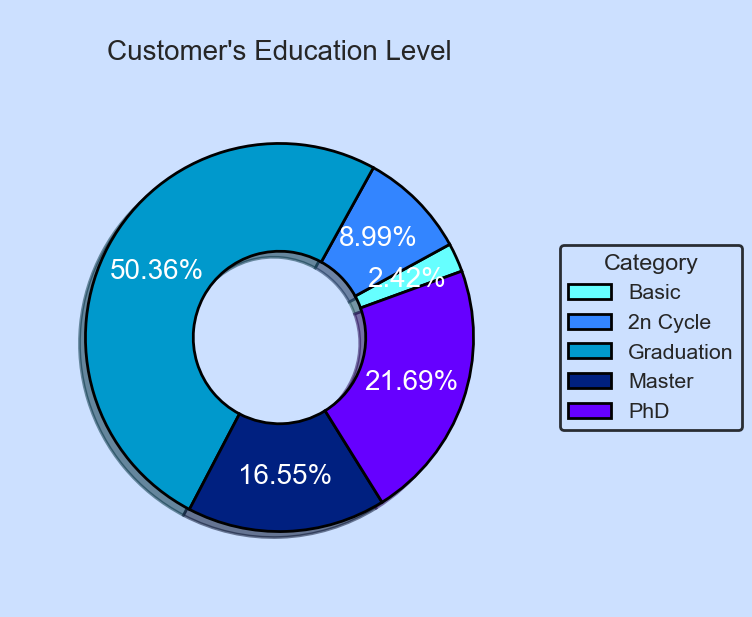

In [49]:
print(f"Let's have a look on the customer's education :")
plt.subplots(figsize=(7, 7))

labels = "Basic","2n Cycle", "Graduation", "Master", "PhD"
size = 0.5

wedges, texts, autotexts = plt.pie([df["Education"].value_counts()[0],
                                    df["Education"].value_counts()[1],
                                    df["Education"].value_counts()[2],
                                    df["Education"].value_counts()[3],
                                    df["Education"].value_counts()[4]],
                                    explode = (0,0,0,0,0),
                                    textprops=dict(size= 20, color= "white"),
                                    autopct="%.2f%%", 
                                    pctdistance = 0.72,
                                    radius=.9, 
                                    colors = ["#66ffff","#3385ff","#0099cc","#002080","#6600ff"],
                                    shadow = True,
                                    wedgeprops=dict(width = size, edgecolor = "black", 
                                    linewidth = 2),
                                    startangle = 20)

plt.legend(wedges, labels, title="Category",loc="center left",bbox_to_anchor=(1, 0, 0.5, 1), edgecolor = "black")
plt.title("\nCustomer's Education Level",fontsize=20)
plt.show()

**Insights:**

- Customers have three education levels : Basic, 2n Cycle, Graduation, Master, PhD
- 50.41% have completed graduation, 16.50% are doing masters, 21.70% are persuing PhD, 8.95% are in 2n Cycle study and 2.44% have done basic education 

## Education Level-wise Spending Distribution

Let's have a look on the distribution of customer's income and spending on basis of education level :


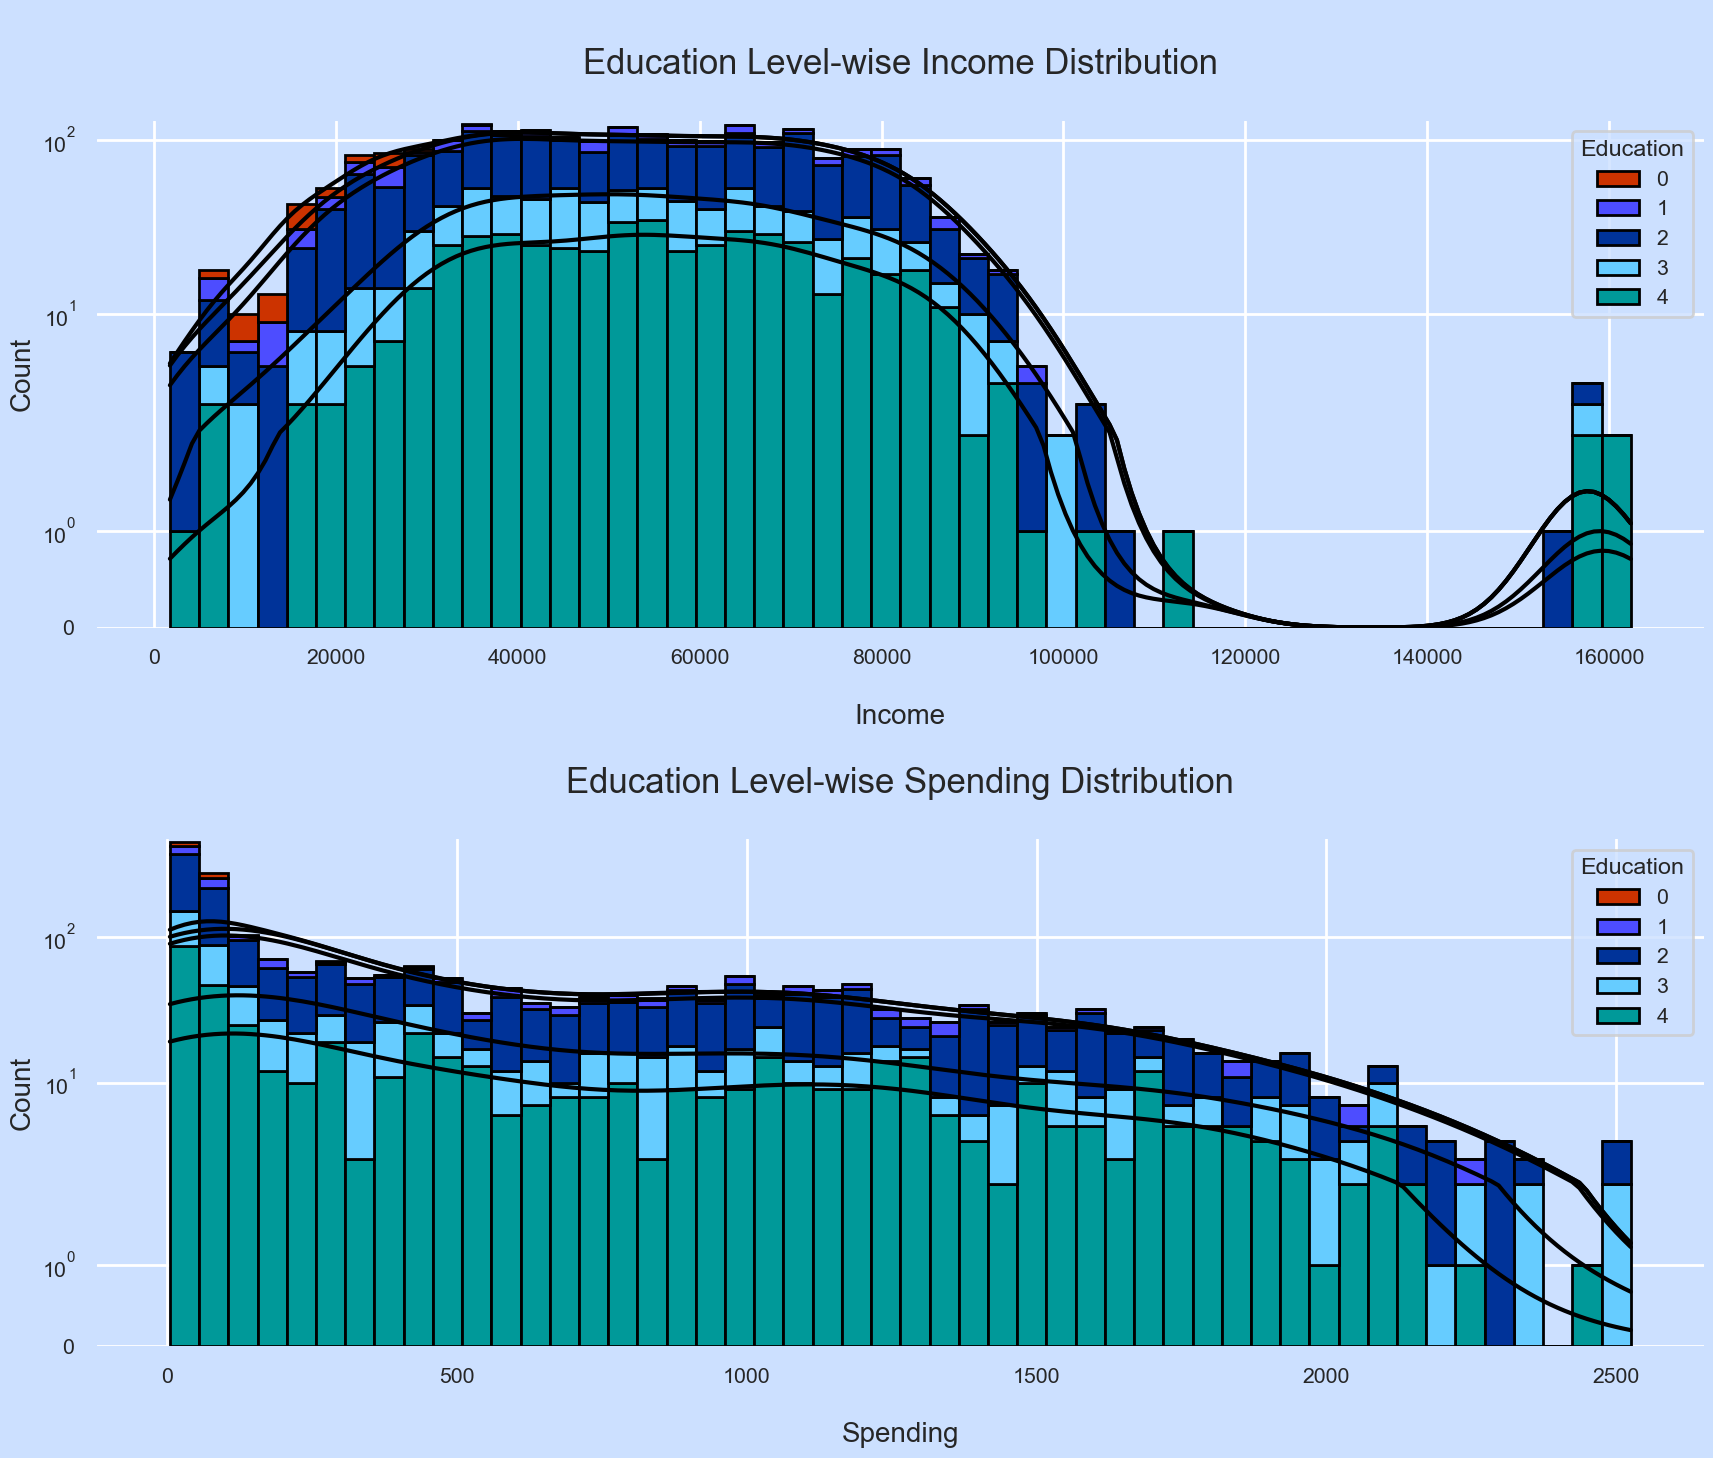

In [50]:
print(f"Let's have a look on the distribution of customer's income and spending on basis of education level :")

_, axes = plt.subplots(2,1,figsize=(20,16),sharex=False)
plt.tight_layout(pad=7.0)

colors = ["#cc2900","#0000ff","#66ffff", "#009999","#99ff66"]
colors2 = ["#cc3300","#4d4dff","#003399","#66ccff","#009999"]
sns.histplot(data=df,x="Income",hue="Education",multiple="stack",palette=colors2,ax=axes[0],kde=True,bins=50,alpha=1,fill=True,edgecolor="black")
axes[0].lines[0].set_color("000000")
axes[0].lines[1].set_color("000000")
axes[0].lines[2].set_color("000000")
axes[0].lines[3].set_color("000000")
axes[0].lines[4].set_color("000000")

axes[0].set_yscale("symlog")
axes[0].set_title("\nEducation Level-wise Income Distribution\n",fontsize=25)
axes[0].set_ylabel("Count",fontsize=20)
axes[0].set_xlabel("\nIncome",fontsize=20)

sns.histplot(data=df,x="Total_Spending",hue="Education",multiple="stack",palette=colors2,ax=axes[1],kde=True,bins=50,alpha=1,fill=True,edgecolor="black")
axes[1].lines[0].set_color("000000")
axes[1].lines[1].set_color("000000")
axes[1].lines[2].set_color("000000")
axes[1].lines[3].set_color("000000")
axes[1].lines[4].set_color("000000")
axes[1].set_yscale("symlog")
axes[1].set_title("\nEducation Level-wise Spending Distribution\n",fontsize=25)
axes[1].set_ylabel("Count",fontsize=20)
axes[1].set_xlabel("\nSpending",fontsize=20)

sns.despine(left=True, bottom=True)
plt.show()

**Insights:**

- Most of the undergraduate level customer's income range is in between 10000 to 80000 and spending in between 0 to 1400.
- Most of the graduate level customer's income range is in between 20000 to 85000 and spending in between 0 to 2000.
- Most of the postgraduate level customer's income range is in between 30000 to 80000 and spending in between 0 to 2000.

### Customer's Children Count

Let's have a look on the distribution of customer's children :


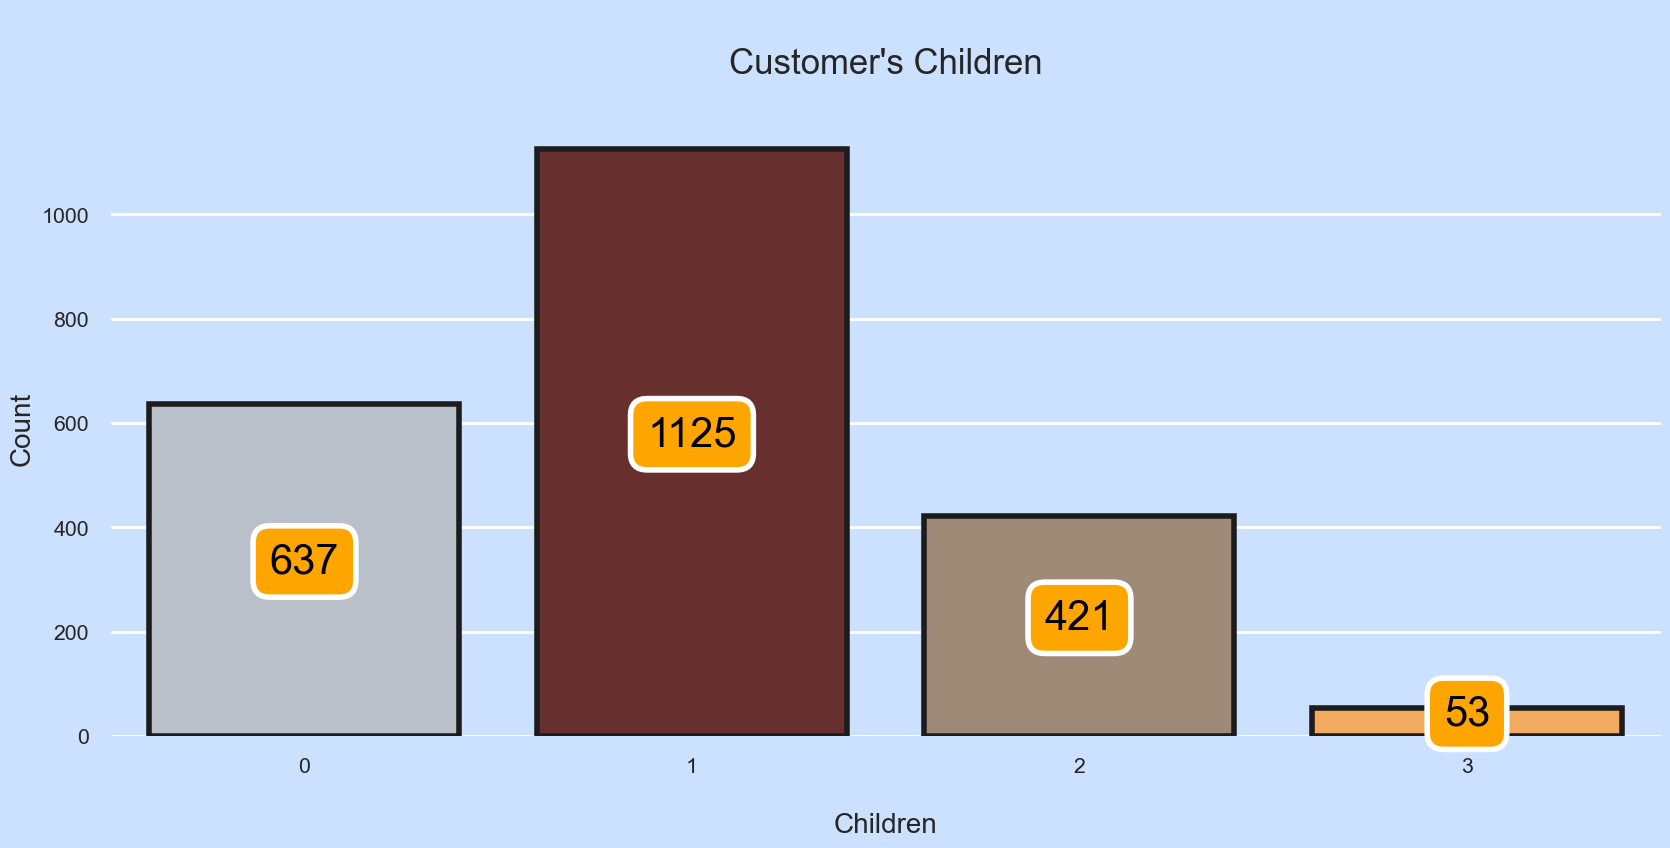

In [51]:
print(f"Let's have a look on the distribution of customer's children :")
plt.subplots(figsize=(20, 8))
p = sns.countplot(x=df["Children"],palette=["#B9C0C9","#682F2F", "#9F8A78","#F3AB60"], saturation=1,edgecolor = "#1c1c1c", linewidth = 4)
p.axes.set_yscale("linear")
p.axes.set_title("\nCustomer's Children\n",fontsize=25)
p.axes.set_ylabel("Count",fontsize=20)
p.axes.set_xlabel("\nChildren",fontsize=20)
p.axes.set_xticklabels(p.get_xticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "orange", "edgecolor": "white", "linewidth" : 4, "alpha": 1})

sns.despine(left=True, bottom=True)
plt.show()

**Report:**

- 632 customers have no child.
- Most of the customers have one child.
- 416 customers have two child.
- 50 customers have three child.

## Final report

We found outliers in the following columns:
- Wines
- Fruits
- Meat
- Fish
- Sweets
- Gold
- Age
- Total_Spending

We also found multicollinearity between these columns:
- Total_Spending
- Wines
- Fruits
- Meat
- Fish
- Sweets
- Gold
So we have to handle those in feature engineering steps.

- We removed the ID column because it is only a unique identifier and does not help in building the model.
- The Z_CostContact and Z_Revenue columns contain the same value in every row. Since they have no variation, they were removed from the dataset.
- Some columns do not provide much useful information on their own. During feature engineering, we will combine or transform them to create new, more meaningful features.